In [9]:
# Install all dependencies
!pip install -q openenv-core==0.2.3
!pip install -q trl transformers accelerate peft datasets
!pip install -q matplotlib pandas numpy

# Clone repo
!rm -rf /content/orbital-anomaly-openenv
!git clone https://github.com/umed-indulkar/orbital-anomaly-openenv.git

# Restart imports path
import sys
sys.path.insert(0, "/content/orbital-anomaly-openenv")

Cloning into 'orbital-anomaly-openenv'...
remote: Enumerating objects: 162, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 162 (delta 80), reused 124 (delta 46), pack-reused 0 (from 0)
Receiving objects: 100% (162/162), 262.53 KiB | 11.41 MiB/s, done.
Resolving deltas: 100% (80/80), done.


In [14]:
import torch
import json
import re
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import Dataset

from server.orbital_anomaly_openenv_environment import OrbitalAnomalyOpenenvEnvironment
from models import OrbitalAnomalyOpenenvAction

print("All imports successful")

All imports successful


In [15]:
env = OrbitalAnomalyOpenenvEnvironment()
obs = env.reset(task_id="easy")
print(obs)

done=False reward=0.4501 metadata={'step': 0, 'episode_id': '1f340302-6f24-4663-bec2-5b8d5dd45f7c', 'version': '2.0', 'obs_dropout': ['solar_array_current']} battery_level=38.0 solar_efficiency=0.6317 thermal_temp=38.0 comms_signal=0.9 payload_on=True safe_mode=False task_id='easy' mission_status='stable' battery_soc=38.0 bus_voltage=25.8 panel_health=0.85 solar_array_current=-1.0 charge_controller_health=0.9 power_bus_redundancy=True attitude_error_deg=42.0 sun_vector_alignment=0.7431 reaction_wheel_momentum=0.25 gyro_bias=0.8 star_tracker_available=True wheel_saturation_level=0.25 battery_temp=8.0 payload_temp=38.0 avionics_temp=32.0 radiator_efficiency=0.95 heater_state=False thermal_loop_health=0.95 antenna_pointing_error=18.0 transmitter_power=4.5 bit_error_rate=0.008 uplink_margin=9.0 packet_loss_ratio=0.06 command_latency_ms=180.0 sunlit=True eclipse_timer=0 ground_station_visible=True radiation_zone=False observation_window_active=False


In [16]:
VALID_ACTIONS = [
    "rotate_to_sun", "disable_payload", "reboot_comms",
    "enter_safe_mode", "switch_power_bus", "noop"
]

def parse_action(text: str) -> str:
    """Extract action from model output. Return 'noop' if nothing found."""
    text_lower = text.lower().strip()
    for action in VALID_ACTIONS:
        if action in text_lower:
            return action
    return "noop"

def obs_to_prompt(obs) -> str:
    """Convert observation to text prompt for the model."""
    return f"""You are controlling a spacecraft. Choose ONE action.

Current telemetry:
- battery_soc: {obs.battery_level:.1f}%
- payload_temp: {obs.thermal_temp:.1f}C
- comms_signal: {obs.comms_signal:.3f}
- mission_status: {obs.mission_status}
- payload_on: {obs.payload_on}
- sunlit: {getattr(obs, 'sunlit', True)}
- attitude_error_deg: {getattr(obs, 'attitude_error_deg', 0.0):.1f}

Actions: rotate_to_sun, disable_payload, reboot_comms, enter_safe_mode, switch_power_bus, noop

Reply with ONLY the action name."""

def run_episode(model, tokenizer, task_id="easy", max_steps=12):
    """Run one episode, return total reward."""
    env = OrbitalAnomalyOpenenvEnvironment()
    result_obs = env.reset(task_id=task_id)

    total_reward = 0.0

    for step in range(max_steps):
        if env._check_done():
            break

        prompt = obs_to_prompt(result_obs)

        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=15,
                temperature=0.7,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id
            )

        generated = tokenizer.decode(
            outputs[0][inputs['input_ids'].shape[1]:],
            skip_special_tokens=True
        )
        action_str = parse_action(generated)

        action = OrbitalAnomalyOpenenvAction(action_type=action_str)
        result_obs = env.step(action)
        total_reward += float(result_obs.reward or 0.001)

    return total_reward / max_steps  # normalized average reward

In [17]:
model_name = "Qwen/Qwen2.5-1.5B-Instruct"

print(f"Loading {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)
print("Model loaded.")

Loading Qwen/Qwen2.5-1.5B-Instruct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded.


In [18]:
print("Evaluating baseline (before training)...")
baseline_rewards = []
for i in range(10):
    r = run_episode(model, tokenizer, task_id="easy")
    baseline_rewards.append(r)
    print(f"  Episode {i+1}: {r:.3f}")

baseline_mean = np.mean(baseline_rewards)
print(f"\nBaseline mean reward: {baseline_mean:.3f}")

Evaluating baseline (before training)...
  Episode 1: 0.147
  Episode 2: 0.147
  Episode 3: 0.800
  Episode 4: 0.906
  Episode 5: 0.147
  Episode 6: 0.147
  Episode 7: 0.147
  Episode 8: 0.147
  Episode 9: 0.147
  Episode 10: 0.147

Baseline mean reward: 0.288


In [24]:
# ═══════════════════════════════════════════════════════
# CELL 6: COMPLETE FIXED TRAINING LOOP
# Same notebook structure, fixes flat reward issue by choosing ONLY valid actions
# instead of random vocabulary tokens.
# ═══════════════════════════════════════════════════════

from torch.optim import SGD
import torch
import gc
import numpy as np

# Memory-safe settings
model.train()
model.config.use_cache = False

if hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable()

gc.collect()
torch.cuda.empty_cache()

optimizer = SGD(model.parameters(), lr=1e-5)
episode_rewards = []

NUM_TRAINING_EPISODES = 80

print("Starting training...")

for episode in range(NUM_TRAINING_EPISODES):

    env = OrbitalAnomalyOpenenvEnvironment()
    obs = env.reset(task_id="easy")

    episode_log_probs = []
    episode_reward_total = 0.0

    for step in range(12):

        if env._check_done():
            break

        prompt = obs_to_prompt(obs)

        # =====================================================
        # SCORE ONLY VALID ACTIONS
        # =====================================================
        action_scores = []

        for act in VALID_ACTIONS:
            txt = prompt + "\n" + act

            inputs = tokenizer(
                txt,
                return_tensors="pt",
                truncation=True,
                max_length=128
            ).to(model.device)

            with torch.amp.autocast("cuda"):
                outputs = model(**inputs)
                score = outputs.logits[:, -1, :].mean()

            action_scores.append(score)

            del outputs, inputs
            torch.cuda.empty_cache()

        scores_tensor = torch.stack(action_scores)
        probs = torch.softmax(scores_tensor, dim=0)

        # Sample one valid action
        idx = torch.multinomial(probs, 1).item()

        action_str = VALID_ACTIONS[idx]
        log_prob = torch.log(probs[idx] + 1e-9)

        # =====================================================
        # EXECUTE ACTION
        # =====================================================
        action = OrbitalAnomalyOpenenvAction(action_type=action_str)

        obs = env.step(action)

        reward = float(obs.reward or 0.001)

        episode_log_probs.append(log_prob)
        episode_reward_total += reward

        del probs, scores_tensor
        torch.cuda.empty_cache()

    # =========================================================
    # END OF EPISODE
    # =========================================================
    avg_reward = episode_reward_total / max(1, len(episode_log_probs))
    episode_rewards.append(avg_reward)

    # Policy gradient update
    if episode_log_probs:
        policy_loss = -avg_reward * torch.stack(episode_log_probs).mean()

        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

    gc.collect()
    torch.cuda.empty_cache()

    if episode % 10 == 0:
        recent_mean = (
            np.mean(episode_rewards[-10:])
            if len(episode_rewards) >= 10
            else avg_reward
        )

        print(
            f"Episode {episode:3d} | "
            f"Reward: {avg_reward:.3f} | "
            f"Recent mean: {recent_mean:.3f}"
        )

print("Training complete.")

Starting training...
Episode   0 | Reward: 0.822 | Recent mean: 0.822
Episode  10 | Reward: 0.860 | Recent mean: 0.860
Episode  20 | Reward: 0.883 | Recent mean: 0.873
Episode  30 | Reward: 0.909 | Recent mean: 0.862
Episode  40 | Reward: 0.915 | Recent mean: 0.873
Episode  50 | Reward: 0.940 | Recent mean: 0.884
Episode  60 | Reward: 0.902 | Recent mean: 0.886
Episode  70 | Reward: 0.945 | Recent mean: 0.876
Training complete.


In [25]:
print("Evaluating after training...")
post_rewards = []
for i in range(10):
    r = run_episode(model, tokenizer, task_id="easy")
    post_rewards.append(r)

post_mean = np.mean(post_rewards)
print(f"Post-training mean reward: {post_mean:.3f}")
print(f"Improvement: {baseline_mean:.3f} → {post_mean:.3f} "
      f"(+{((post_mean - baseline_mean)/baseline_mean*100):.1f}%)")

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Evaluating after training...
Post-training mean reward: 0.799
Improvement: 0.288 → 0.799 (+177.4%)


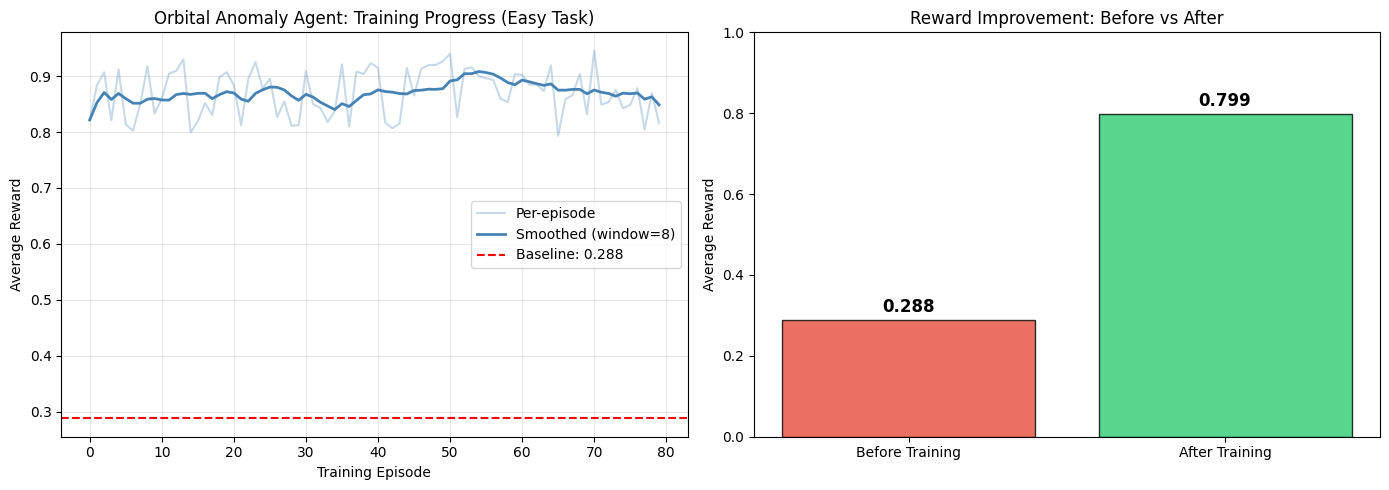


Saved reward_curve.png


In [26]:
def smooth(values, window=5):
    return [np.mean(values[max(0,i-window):i+1]) for i in range(len(values))]

smoothed = smooth(episode_rewards, window=8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training curve
ax1.plot(episode_rewards, alpha=0.3, color='steelblue', label='Per-episode')
ax1.plot(smoothed, color='steelblue', linewidth=2, label='Smoothed (window=8)')
ax1.axhline(y=baseline_mean, color='red', linestyle='--',
            label=f'Baseline: {baseline_mean:.3f}')
ax1.set_xlabel('Training Episode')
ax1.set_ylabel('Average Reward')
ax1.set_title('Orbital Anomaly Agent: Training Progress (Easy Task)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Before/After comparison
ax2.bar(['Before Training', 'After Training'],
        [baseline_mean, post_mean],
        color=['#e74c3c', '#2ecc71'],
        alpha=0.8, edgecolor='black')
ax2.set_ylabel('Average Reward')
ax2.set_title('Reward Improvement: Before vs After')
ax2.set_ylim(0, 1.0)
for i, v in enumerate([baseline_mean, post_mean]):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('reward_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved reward_curve.png")